# Ridge vs. Lasso Coefficient Shrinkage Paths

L1 regularization (Lasso) and L2 regularization (Ridge) reduce overfitting by adding penalty constraints to linear regressions:
- **Lasso (L1):** Adds absolute weights sum penalty ($\sum |\beta_j|$), driving non-informative coefficients to exactly zero (enables feature selection/sparsity).
- **Ridge (L2):** Adds squared weights sum penalty ($\sum \beta_j^2$), shrinking coefficients asymptotically toward zero.
This notebook generates 15 features, fits both Ridge and Lasso models, and plots side-by-side shrinkage path subplots.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso

# Generate synthetic linear regression data (100 samples, 15 features, 6 informative features)
np.random.seed(190)
n_samples = 100
n_features = 15

X = np.random.normal(0, 1.0, (n_samples, n_features))
# Set only 6 features to be active
true_coefs = np.array([3.5, -2.5, 1.8, -1.2, 0.8, -0.5] + [0.0]*9)
y = np.dot(X, true_coefs) + np.random.normal(0, 0.5, n_samples)

df_reg = pd.DataFrame(X, columns=[f"Feat_{i+1:02d}" for i in range(n_features)])
df_reg['Target'] = y
df_reg.head(10)



,Feat_01,Feat_02,Feat_03,Feat_04,Feat_05,Feat_06,Feat_07,Feat_08,Feat_09,Feat_10,Feat_11,Feat_12,Feat_13,Feat_14,Feat_15,Target
0,0.709691,1.367792,1.298705,0.958357,0.319111,0.344276,0.783498,-0.008030,0.689647,0.016362,-1.954949,-0.615480,1.063208,1.382660,1.371954,0.499070
1,0.907351,-2.043078,1.965225,-0.444544,-0.481514,-1.087535,-1.921103,2.143725,-0.830504,-2.059652,0.163159,0.371622,-1.647659,-1.253271,-1.290314,12.817402
2,-0.039314,0.572415,-0.003563,-0.434982,0.822385,0.748355,-0.883171,-1.032544,-0.162046,0.039648,0.203343,1.033231,-0.714777,-0.332361,1.664431,-0.195335
3,0.545875,-1.522978,-0.388114,0.625952,-0.517165,0.990014,0.610109,0.795385,-0.338693,1.534268,1.646900,-0.376827,0.188943,0.851729,-0.072246,2.542525
4,0.145741,0.231469,-0.024192,-1.206868,-0.107698,-0.532446,0.135539,-1.258142,1.186495,0.495644,-0.380557,1.189687,-0.223455,-1.090499,0.070550,2.248730
5,-0.987745,-0.549125,-0.545743,0.301504,-0.679459,1.225710,2.139134,-0.348417,-0.203504,0.681700,-0.499235,0.289323,-1.439119,0.204697,-2.011622,-4.158501
6,0.374562,1.946524,-0.322553,-0.437047,1.773104,1.575450,0.970527,-0.497230,0.364600,1.883748,0.686528,-0.328212,1.473249,0.008068,-0.640737,-3.224332
7,1.946476,0.978225,1.605109,1.013988,-1.118656,-1.962562,-0.233127,0.645817,-0.343788,-0.380021,0.102075,-0.184412,-0.677685,0.434502,1.019483,6.899212
8,1.307941,1.458287,1.457022,-0.586296,0.873218,-0.432864,-1.095609,0.566455,0.118352,-0.635451,2.308252,-0.253693,-0.005197,-0.343328,-1.868211,5.021215
9,-0.207088,-0.858935,0.605840,0.662612,0.993986,-0.473254,0.934343,-0.871308,0.616292,-0.519461,0.919417,-0.680931,-0.206493,0.807724,-1.295161,3.469126


## Regularization Paths Fitting

We fit Ridge and Lasso regressors across a log regularizer alpha array ranging from $10^{-4}$ to $10^3$.



In [2]:
alphas = np.logspace(-4, 3, 100)

ridge_coefs = []
lasso_coefs = []

for a in alphas:
    # Ridge L2
    ridge = Ridge(alpha=a)
    ridge.fit(X, y)
    ridge_coefs.append(ridge.coef_)
    
    # Lasso L1 (max_iter increased for convergence stability)
    lasso = Lasso(alpha=a, max_iter=5000)
    lasso.fit(X, y)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

print(f"Computed Ridge Coefficient Matrix: {ridge_coefs.shape}")
print(f"Computed Lasso Coefficient Matrix: {lasso_coefs.shape}")



Computed Ridge Coefficient Matrix: (100, 15)
Computed Lasso Coefficient Matrix: (100, 15)


## Coefficient Shrinkage Paths Comparison

Using a 1x2 Matplotlib subplot grid, we compare Ridge's asymptotic decay against Lasso's sparse zeroing behavior across log alphas.



<cell>:23: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



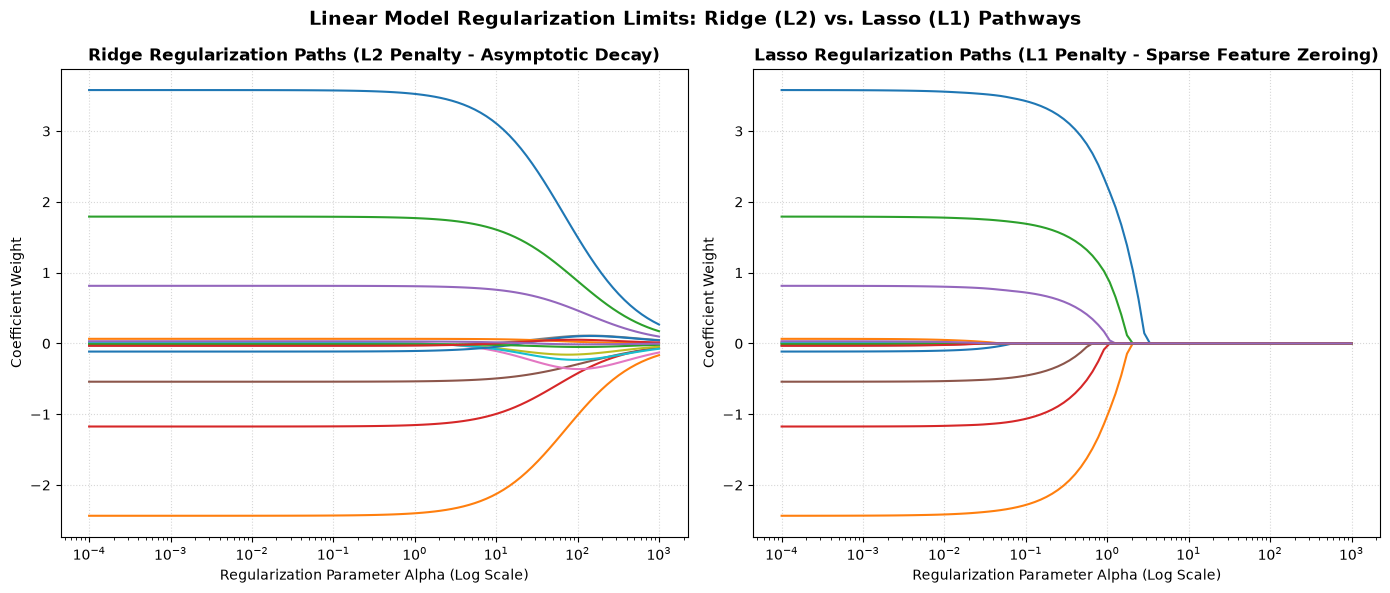

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. Ridge Shrinkage Paths (L2)
for i in range(n_features):
    ax1.plot(alphas, ridge_coefs[:, i], label=f"Feat {i+1:02d}" if i < 6 else None)
ax1.set_xscale('log')
ax1.set_title('Ridge Regularization Paths (L2 Penalty - Asymptotic Decay)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Regularization Parameter Alpha (Log Scale)')
ax1.set_ylabel('Coefficient Weight')
ax1.grid(True, linestyle=':', alpha=0.5)

# 2. Lasso Shrinkage Paths (L1)
for i in range(n_features):
    ax2.plot(alphas, lasso_coefs[:, i], label=f"Feat {i+1:02d}" if i < 6 else None)
ax2.set_xscale('log')
ax2.set_title('Lasso Regularization Paths (L1 Penalty - Sparse Feature Zeroing)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Regularization Parameter Alpha (Log Scale)')
ax2.set_ylabel('Coefficient Weight')
ax2.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Linear Model Regularization Limits: Ridge (L2) vs. Lasso (L1) Pathways', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
